In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import KNNImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [27]:
# Load datasets
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
train_df.head()

C:\Users\harsh\AppData\Local\Temp\ipykernel_7912\3329951649.py:2: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv("train.csv")


,ID,Customer_ID,Month,Name,Age,Number,Profession,Income_Annual,Base_Salary_PerMonth,Total_Bank_Accounts,...,Credit_Mix,Current_Debt_Outstanding,Ratio_Credit_Utilization,Credit_History_Age,Payment_of_Min_Amount,Per_Month_EMI,Monthly_Investment,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x522a,CUS_0x2dbf,May,Abhishek Vishnoiw,51,370-51-2390,Musician,101583.48,NaN,5,...,Standard,50.93,34.462154,24 Years and 1 Months,No,190.811017,630.0157894388726,Low_spent_Large_value_payments,314.0021934422197,Standard
1,0x6091,CUS_0x8167,August,Freifeldu,23,721-85-0529,Writer,101926.95,8635.9125,4,...,_,1058,39.693812,20 Years and 5 Months,No,70.587681,662.8039273360225,Low_spent_Medium_value_payments,410.1996419555151,Standard
2,0xcb5f,CUS_0x3a0b,February,NaN,49,618-96-2558,Writer,158871.12,NaN,0,...,Good,576.48,39.367225,19 Years and 0 Months,No,86.905860,746.8059854204569,Low_spent_Medium_value_payments,742.5141542054829,Standard
3,0x17dbc,CUS_0x9a4b,March,Alex Dobuzinskiso,40,817-31-4270,Doctor,60379.28,NaN,5,...,Standard,725.39,29.061701,17 Years and 1 Months,NM,90.906385,166.41865803064803,High_spent_Medium_value_payments,473.13562343490486,Standard
4,0x225b3,CUS_0x253a,June,NaN,17,580-53-4920,Accountant,50050.83,4085.9025,9,...,Bad,3419.1,30.386321,4 Years and 6 Months,Yes,190.445060,56.789441169542684,High_spent_Large_value_payments,401.3557486786916,Poor


In [28]:
train_df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'Number', 'Profession',
       'Income_Annual', 'Base_Salary_PerMonth', 'Total_Bank_Accounts',
       'Total_Credit_Cards', 'Rate_Of_Interest', 'Total_Current_Loans',
       'Loan_Type', 'Delay_from_due_date', 'Total_Delayed_Payments',
       'Credit_Limit', 'Total_Credit_Enquiries', 'Credit_Mix',
       'Current_Debt_Outstanding', 'Ratio_Credit_Utilization',
       'Credit_History_Age', 'Payment_of_Min_Amount', 'Per_Month_EMI',
       'Monthly_Investment', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [29]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        80000 non-null  object 
 1   Customer_ID               80000 non-null  object 
 2   Month                     80000 non-null  object 
 3   Name                      71971 non-null  object 
 4   Age                       80000 non-null  object 
 5   Number                    80000 non-null  object 
 6   Profession                80000 non-null  object 
 7   Income_Annual             80000 non-null  object 
 8   Base_Salary_PerMonth      67968 non-null  float64
 9   Total_Bank_Accounts       80000 non-null  int64  
 10  Total_Credit_Cards        80000 non-null  int64  
 11  Rate_Of_Interest          80000 non-null  int64  
 12  Total_Current_Loans       80000 non-null  object 
 13  Loan_Type                 70843 non-null  object 
 14  Delay_

In [30]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Base_Salary_PerMonth,67968.0,4189.211406,3181.371100,303.645417,1623.664167,3086.683333,5950.863333,15204.633333
Total_Bank_Accounts,80000.0,17.046287,116.953761,-1.000000,4.000000,6.000000,7.000000,1798.000000
Total_Credit_Cards,80000.0,22.175438,128.083595,0.000000,4.000000,5.000000,7.000000,1499.000000
Rate_Of_Interest,80000.0,72.261350,466.370837,1.000000,8.000000,14.000000,20.000000,5797.000000
Delay_from_due_date,80000.0,21.081663,14.855210,-5.000000,10.000000,18.000000,28.000000,67.000000
Total_Credit_Enquiries,78451.0,28.153115,194.812201,0.000000,3.000000,6.000000,9.000000,2597.000000
Ratio_Credit_Utilization,80000.0,32.273436,5.116887,20.000000,28.052046,32.292625,36.482439,49.564519
Per_Month_EMI,80000.0,1414.789973,8323.122028,0.000000,30.305498,68.839655,160.585877,82331.000000


In [31]:
train_df.describe(exclude=np.number).T

,count,unique,top,freq
ID,80000,80000,0x522a,1
Customer_ID,80000,12500,CUS_0x4a7,8
Month,80000,8,June,10035
Name,71971,10139,Stevex,37
Age,80000,1466,28,2247
Number,80000,12501,#F%$D@*&8,4443
Profession,80000,16,_______,5691
Income_Annual,80000,17821,20867.67,13
Total_Current_Loans,80000,381,3,11543
Loan_Type,70843,6260,Not Specified,1105


In [32]:
columns_to_clean = ['Age', 'Income_Annual', 'Current_Debt_Outstanding', 'Monthly_Investment', 'Monthly_Balance','Total_Current_Loans','Total_Delayed_Payments','Credit_Limit']
# Removing non-numeric characters and converting to numeric
for col in columns_to_clean:
    train_df[col] = pd.to_numeric(train_df[col].replace('[^0-9.]', '', regex=True), errors='coerce')
    test_df[col] = pd.to_numeric(test_df[col].replace('[^0-9.]', '', regex=True), errors='coerce')


In [33]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,80000.0,1.194980e+02,6.860849e+02,14.000000,25.000000,33.000000,42.000000,8.698000e+03
Income_Annual,80000.0,1.747652e+05,1.422707e+06,7005.930000,19419.650000,37482.370000,72678.605000,2.419806e+07
Base_Salary_PerMonth,67968.0,4.189211e+03,3.181371e+03,303.645417,1623.664167,3086.683333,5950.863333,1.520463e+04
Total_Bank_Accounts,80000.0,1.704629e+01,1.169538e+02,-1.000000,4.000000,6.000000,7.000000,1.798000e+03
Total_Credit_Cards,80000.0,2.217544e+01,1.280836e+02,0.000000,4.000000,5.000000,7.000000,1.499000e+03
Rate_Of_Interest,80000.0,7.226135e+01,4.663708e+02,1.000000,8.000000,14.000000,20.000000,5.797000e+03
Total_Current_Loans,80000.0,1.104204e+01,6.388997e+01,0.000000,2.000000,3.000000,6.000000,1.496000e+03
Delay_from_due_date,80000.0,2.108166e+01,1.485521e+01,-5.000000,10.000000,18.000000,28.000000,6.700000e+01
Total_Delayed_Payments,74405.0,3.120578e+01,2.289401e+02,0.000000,9.000000,14.000000,18.000000,4.397000e+03
Credit_Limit,78309.0,1.046665e+01,6.666356e+00,0.000000,5.360000,9.410000,14.850000,3.697000e+01


In [34]:
test_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,1.195566e+02,6.794380e+02,14.000000,25.000000,34.000000,43.000000,8.663000e+03
Income_Annual,20000.0,1.830177e+05,1.456951e+06,7005.930000,19608.182500,37984.650000,73339.920000,2.394266e+07
Base_Salary_PerMonth,17030.0,4.213964e+03,3.192926e+03,303.645417,1634.523387,3124.620833,5991.043125,1.520463e+04
Total_Bank_Accounts,20000.0,1.727125e+01,1.191948e+02,-1.000000,3.000000,6.000000,7.000000,1.798000e+03
Total_Credit_Cards,20000.0,2.367040e+01,1.328779e+02,0.000000,4.000000,6.000000,7.000000,1.499000e+03
Rate_Of_Interest,20000.0,7.328480e+01,4.666405e+02,1.000000,8.000000,13.000000,20.000000,5.789000e+03
Total_Current_Loans,20000.0,9.641650e+00,5.254379e+01,0.000000,2.000000,3.000000,6.000000,1.495000e+03
Delay_from_due_date,20000.0,2.101725e+01,1.487993e+01,-5.000000,10.000000,18.000000,28.000000,6.700000e+01
Total_Delayed_Payments,18593.0,2.990776e+01,2.139848e+02,0.000000,9.000000,14.000000,18.000000,4.360000e+03
Credit_Limit,19600.0,1.046180e+01,6.688357e+00,0.010000,5.290000,9.400000,14.932500,3.649000e+01


In [35]:
train_df.describe(exclude=np.number).T

,count,unique,top,freq
ID,80000,80000,0x522a,1
Customer_ID,80000,12500,CUS_0x4a7,8
Month,80000,8,June,10035
Name,71971,10139,Stevex,37
Number,80000,12501,#F%$D@*&8,4443
Profession,80000,16,_______,5691
Loan_Type,70843,6260,Not Specified,1105
Credit_Mix,80000,4,Standard,29214
Credit_History_Age,72760,404,18 Years and 3 Months,361
Payment_of_Min_Amount,80000,3,Yes,41857


In [36]:
train_df.drop(columns=['Customer_ID','Name','Number'], inplace=True)
test_df.drop(columns=['Customer_ID','Name','Number'], inplace=True)

In [37]:
train_df['Month'].value_counts()

Month
June        10035
August      10025
July        10013
January     10013
May          9999
April        9987
February     9985
March        9943
Name: count, dtype: int64

In [38]:
test_df['Profession'].value_counts()

Profession
_______          1371
Entrepreneur     1317
Lawyer           1302
Developer        1289
Engineer         1283
Media_Manager    1273
Accountant       1264
Architect        1255
Scientist        1255
Doctor           1244
Teacher          1225
Mechanic         1196
Musician         1194
Writer           1193
Journalist       1176
Manager          1163
Name: count, dtype: int64

In [39]:
# Replace '_______' with NaN in the 'Profession' column
train_df['Profession'] = train_df['Profession'].replace('_______', np.nan)
test_df['Profession'] = test_df['Profession'].replace('_______', np.nan)

# Verify the replacement
print(train_df['Profession'].value_counts(dropna=False))

Profession
NaN              5691
Lawyer           5273
Architect        5100
Mechanic         5095
Engineer         5067
Scientist        5044
Accountant       5007
Teacher          4990
Media_Manager    4959
Developer        4946
Journalist       4909
Entrepreneur     4857
Doctor           4843
Manager          4810
Musician         4717
Writer           4692
Name: count, dtype: int64


In [40]:
train_df['Loan_Type'].value_counts()

Loan_Type
Not Specified                                                                            1105
Credit-Builder Loan                                                                      1024
Student Loan                                                                             1021
Personal Loan                                                                            1014
Debt Consolidation Loan                                                                  1007
                                                                                         ... 
Debt Consolidation Loan, Not Specified, Home Equity Loan, and Personal Loan                 2
Not Specified, Debt Consolidation Loan, Mortgage Loan, Mortgage Loan, and Payday Loan       2
Debt Consolidation Loan, Payday Loan, Payday Loan, and Personal Loan                        2
Debt Consolidation Loan, Payday Loan, Payday Loan, and Auto Loan                            2
Debt Consolidation Loan, Auto Loan, Debt Consolida

In [41]:
test_df['Loan_Type'].value_counts()

Loan_Type
Not Specified                                                                                                                                             303
Home Equity Loan                                                                                                                                          266
Personal Loan                                                                                                                                             258
Debt Consolidation Loan                                                                                                                                   257
Credit-Builder Loan                                                                                                                                       256
                                                                                                                                                         ... 
Payday Loan, Auto Loan, Auto Loan, Credit-

In [42]:
train_df['Credit_Mix'].value_counts()

Credit_Mix
Standard    29214
Good        19455
_           16108
Bad         15223
Name: count, dtype: int64

In [43]:
test_df['Credit_Mix'].value_counts()

Credit_Mix
Standard    7265
Good        4882
_           4087
Bad         3766
Name: count, dtype: int64

In [44]:
# Replace '_' with NaN in the 'Credit_Mix' column
train_df['Credit_Mix'] = train_df['Credit_Mix'].replace('_', np.nan)
test_df['Credit_Mix'] = test_df['Credit_Mix'].replace('_', np.nan)

# Verify the replacement
print(train_df['Credit_Mix'].value_counts(dropna=False))

Credit_Mix
Standard    29214
Good        19455
NaN         16108
Bad         15223
Name: count, dtype: int64


In [45]:
train_df['Credit_History_Age'].value_counts()

Credit_History_Age
18 Years and 3 Months     361
15 Years and 11 Months    361
19 Years and 4 Months     358
19 Years and 3 Months     354
17 Years and 9 Months     349
                         ... 
0 Years and 3 Months       18
0 Years and 2 Months       12
33 Years and 7 Months      11
33 Years and 8 Months       9
0 Years and 1 Months        2
Name: count, Length: 404, dtype: int64

In [46]:
def Month_Converter(val):
    if pd.notnull(val):
        years = int(val.split(' ')[0])
        month = int(val.split(' ')[3])
        return (years*12)+month
    else:
        return val
    
train_df['Credit_History_Age'] = train_df['Credit_History_Age'].apply(lambda x: Month_Converter(x)).astype(float)
test_df['Credit_History_Age'] = test_df['Credit_History_Age'].apply(lambda x: Month_Converter(x)).astype(float)
print(train_df['Credit_History_Age'].value_counts(dropna=False))
print(test_df['Credit_History_Age'].value_counts(dropna=False))

Credit_History_Age
NaN      7240
219.0     361
191.0     361
232.0     358
231.0     354
         ... 
3.0        18
2.0        12
403.0      11
404.0       9
1.0         2
Name: count, Length: 405, dtype: int64
Credit_History_Age
NaN      1790
233.0     103
215.0      99
197.0      93
190.0      91
         ... 
403.0       3
2.0         3
404.0       3
33.0        3
3.0         2
Name: count, Length: 404, dtype: int64


In [47]:
train_df['Payment_of_Min_Amount'].value_counts()

Payment_of_Min_Amount
Yes    41857
No     28509
NM      9634
Name: count, dtype: int64

In [48]:
train_df['Payment_Behaviour'].value_counts()

Payment_Behaviour
Low_spent_Small_value_payments      20470
High_spent_Medium_value_payments    14057
Low_spent_Medium_value_payments     11101
High_spent_Large_value_payments     10931
High_spent_Small_value_payments      9034
Low_spent_Large_value_payments       8309
!@9#%8                               6098
Name: count, dtype: int64

In [49]:
test_df['Payment_Behaviour'].value_counts()

Payment_Behaviour
Low_spent_Small_value_payments      5043
High_spent_Medium_value_payments    3483
High_spent_Large_value_payments     2790
Low_spent_Medium_value_payments     2760
High_spent_Small_value_payments     2306
Low_spent_Large_value_payments      2116
!@9#%8                              1502
Name: count, dtype: int64

In [50]:
# Replace '!@9#%8' with NaN in the 'Payment_Behaviour' column
train_df['Payment_Behaviour'] = train_df['Payment_Behaviour'].replace('!@9#%8', np.nan)
test_df['Payment_Behaviour'] = test_df['Payment_Behaviour'].replace('!@9#%8', np.nan)

# Verify the replacement
print(train_df['Payment_Behaviour'].value_counts(dropna=False))
print(test_df['Payment_Behaviour'].value_counts(dropna=False))

Payment_Behaviour
Low_spent_Small_value_payments      20470
High_spent_Medium_value_payments    14057
Low_spent_Medium_value_payments     11101
High_spent_Large_value_payments     10931
High_spent_Small_value_payments      9034
Low_spent_Large_value_payments       8309
NaN                                  6098
Name: count, dtype: int64
Payment_Behaviour
Low_spent_Small_value_payments      5043
High_spent_Medium_value_payments    3483
High_spent_Large_value_payments     2790
Low_spent_Medium_value_payments     2760
High_spent_Small_value_payments     2306
Low_spent_Large_value_payments      2116
NaN                                 1502
Name: count, dtype: int64


In [51]:
train_df['Credit_Score'].value_counts()

Credit_Score
Standard    42539
Poor        23199
Good        14262
Name: count, dtype: int64

In [52]:
train_df['Credit_Score'] = train_df['Credit_Score'].replace('Poor', 0)
train_df['Credit_Score'] = train_df['Credit_Score'].replace('Standard', 1)
train_df['Credit_Score'] = train_df['Credit_Score'].replace('Good', 2)
print(train_df['Credit_Score'].value_counts(dropna=False))

Credit_Score
1    42539
0    23199
2    14262
Name: count, dtype: int64


C:\Users\harsh\AppData\Local\Temp\ipykernel_7912\958937410.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df['Credit_Score'] = train_df['Credit_Score'].replace('Good', 2)


In [53]:
null_value_percentages=(train_df.isna().sum()/train_df.shape[0])*100
null_value_percentages

ID                           0.00000
Month                        0.00000
Age                          0.00000
Profession                   7.11375
Income_Annual                0.00000
Base_Salary_PerMonth        15.04000
Total_Bank_Accounts          0.00000
Total_Credit_Cards           0.00000
Rate_Of_Interest             0.00000
Total_Current_Loans          0.00000
Loan_Type                   11.44625
Delay_from_due_date          0.00000
Total_Delayed_Payments       6.99375
Credit_Limit                 2.11375
Total_Credit_Enquiries       1.93625
Credit_Mix                  20.13500
Current_Debt_Outstanding     0.00000
Ratio_Credit_Utilization     0.00000
Credit_History_Age           9.05000
Payment_of_Min_Amount        0.00000
Per_Month_EMI                0.00000
Monthly_Investment           4.50625
Payment_Behaviour            7.62250
Monthly_Balance              1.18750
Credit_Score                 0.00000
dtype: float64

In [54]:
null_value_percentages_2=(test_df.isna().sum()/train_df.shape[0])*100
null_value_percentages_2

ID                          0.00000
Month                       0.00000
Age                         0.00000
Profession                  1.71375
Income_Annual               0.00000
Base_Salary_PerMonth        3.71250
Total_Bank_Accounts         0.00000
Total_Credit_Cards          0.00000
Rate_Of_Interest            0.00000
Total_Current_Loans         0.00000
Loan_Type                   2.81375
Delay_from_due_date         0.00000
Total_Delayed_Payments      1.75875
Credit_Limit                0.50000
Total_Credit_Enquiries      0.52000
Credit_Mix                  5.10875
Current_Debt_Outstanding    0.00000
Ratio_Credit_Utilization    0.00000
Credit_History_Age          2.23750
Payment_of_Min_Amount       0.00000
Per_Month_EMI               0.00000
Monthly_Investment          1.09250
Payment_Behaviour           1.87750
Monthly_Balance             0.31250
dtype: float64

In [55]:
train_df.describe(exclude=np.number).T

,count,unique,top,freq
ID,80000,80000,0x522a,1
Month,80000,8,June,10035
Profession,74309,15,Lawyer,5273
Loan_Type,70843,6260,Not Specified,1105
Credit_Mix,63892,3,Standard,29214
Payment_of_Min_Amount,80000,3,Yes,41857
Payment_Behaviour,73902,6,Low_spent_Small_value_payments,20470


In [56]:
columns_to_impute_mode=['Profession','Payment_Behaviour']
def fill_missing_with_group_mode(train_df, groupby, column):      
    print("\nNo. of missing values before filling with group mode:", train_df[column].isna().sum())
    
    # Fill with mode or second most frequent value if mode is NaN
    def get_mode_or_second_most(x):
        # Get the most frequent values and sort them by frequency
        freq = x.value_counts()
        if len(freq) > 0 and pd.isna(freq.index[0]):  # Mode is NaN
            return freq.index[1] if len(freq) > 1 else np.nan  # Use second if available
        else:
            return freq.index[0] if len(freq) > 0 else np.nan  # Default to mode
    
    mode_per_group = train_df.groupby(groupby)[column].transform(get_mode_or_second_most)
    train_df[column] = train_df[column].fillna(mode_per_group)

    print("\nNo. of missing values after filling with group mode:", train_df[column].isna().sum())


for col in columns_to_impute_mode:
    fill_missing_with_group_mode(train_df,'ID',col)
for col in columns_to_impute_mode:
    fill_missing_with_group_mode(test_df,'ID',col)  


No. of missing values before filling with group mode: 5691

No. of missing values after filling with group mode: 5691

No. of missing values before filling with group mode: 6098

No. of missing values after filling with group mode: 6098

No. of missing values before filling with group mode: 1371

No. of missing values after filling with group mode: 1371

No. of missing values before filling with group mode: 1502

No. of missing values after filling with group mode: 1502


In [57]:
import re
from sklearn.preprocessing import MultiLabelBinarizer

# Assuming 'train_df' and 'test_df' are your DataFrames

# Step 1: Fill NaN values in 'Loan_Type' with 'Not Specified'
train_df['Loan_Type'] = train_df['Loan_Type'].fillna('Not Specified')
test_df['Loan_Type'] = test_df['Loan_Type'].fillna('Not Specified')

# Step 2: Remove "and" from the 'Loan_Type' column in both train and test sets
train_df['Loan_Type'] = train_df['Loan_Type'].str.replace(r'\band \b', '', regex=True).str.strip()
test_df['Loan_Type'] = test_df['Loan_Type'].str.replace(r'\band \b', '', regex=True).str.strip()

# Step 3: Splitting each entry into a list of loan types in the training set
train_df['Loan_Type_List'] = train_df['Loan_Type'].str.split(', ')

# Step 4: Using MultiLabelBinarizer to create binary columns for each unique loan type
mlb = MultiLabelBinarizer()
loan_type_encoded_train = mlb.fit_transform(train_df['Loan_Type_List'])

# Step 5: Creating a new DataFrame with the encoded loan types for the training set
loan_type_df_train = pd.DataFrame(loan_type_encoded_train, columns=mlb.classes_, index=train_df.index)

# Step 6: Merging the encoded loan types back into the original training DataFrame
train_df = pd.concat([train_df, loan_type_df_train], axis=1).drop(columns=['Loan_Type', 'Loan_Type_List'])

# Step 7: Splitting each entry into a list of loan types in the test set
test_df['Loan_Type_List'] = test_df['Loan_Type'].str.split(', ')

# Step 8: Using the same MultiLabelBinarizer to transform the test set
loan_type_encoded_test = mlb.transform(test_df['Loan_Type_List'])

# Step 9: Creating a new DataFrame with the encoded loan types for the test set
loan_type_df_test = pd.DataFrame(loan_type_encoded_test, columns=mlb.classes_, index=test_df.index)

# Step 10: Merging the encoded loan types back into the original test DataFrame
test_df = pd.concat([test_df, loan_type_df_test], axis=1).drop(columns=['Loan_Type', 'Loan_Type_List'])

# Now both train_df and test_df should have clean binary columns for each unique loan type


In [58]:

# categorical_columns = ['Month','Profession','Loan_Type','Credit_Mix','Payment_of_Min_Amount','Payment_Behaviour']
categorical_columns = ['Month','Profession','Credit_Mix','Payment_of_Min_Amount','Payment_Behaviour']
# Dictionary to store fitted LabelEncoders for each column
label_encoders = {}
# # Initialize the LabelEncoder for Credit_Score
# label_encoder = LabelEncoder()
# Loop through each categorical column in the train set
for column in categorical_columns:
    # if column == 'Credit_Score':
    #     # Skip encoding Credit_Score in the test set
    #     train_df[column] = label_encoder.fit_transform(train_df[column])
    # else:
        # Fit the encoder on the train data
        label_encoders[column] = LabelEncoder()
        train_df[column] = label_encoders[column].fit_transform(train_df[column])

        # Use the same encoder to transform the test data
        test_df[column] = label_encoders[column].transform(test_df[column])

In [59]:
# Initialize the KNNImputer
imputer = KNNImputer(n_neighbors=5)

# Define the columns to impute (excluding 'Credit_Score' for train_df)
columns_to_impute = train_df.loc[:, 'Age':'Monthly_Balance'].columns

# Apply the KNNImputer to these columns
train_df[columns_to_impute] = imputer.fit_transform(train_df[columns_to_impute])
test_df[columns_to_impute] = imputer.transform(test_df[columns_to_impute])

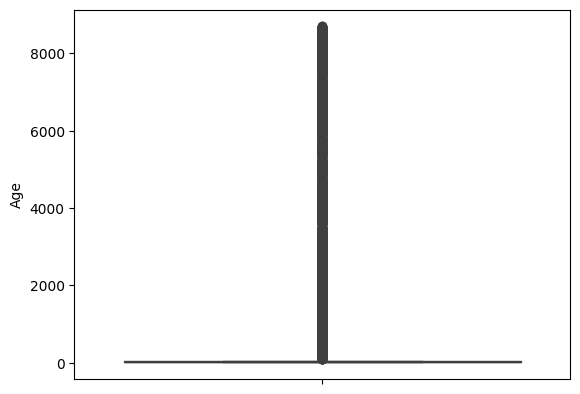

<Figure size 1000x1000 with 0 Axes>

In [165]:
sns.boxplot(train_df["Age"])
plt.figure(figsize=(10, 10))
plt.show()

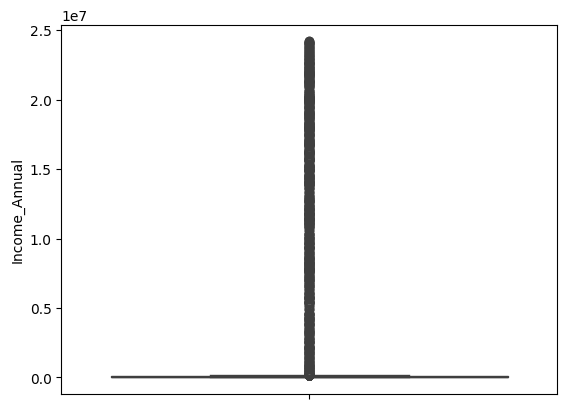

<Figure size 1000x1000 with 0 Axes>

In [166]:
sns.boxplot(train_df["Income_Annual"])
plt.figure(figsize=(10, 10))
plt.show()

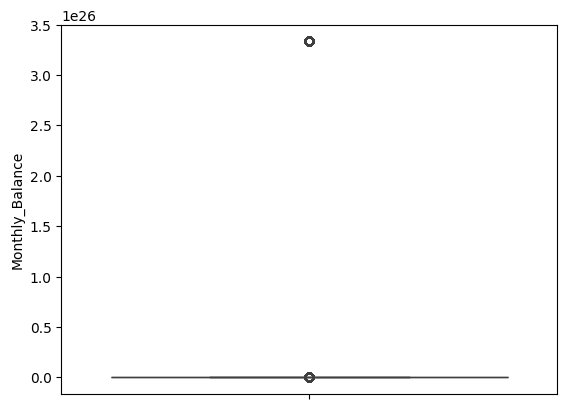

<Figure size 1000x1000 with 0 Axes>

In [167]:
sns.boxplot(train_df["Monthly_Balance"])
plt.figure(figsize=(10, 10))
plt.show()

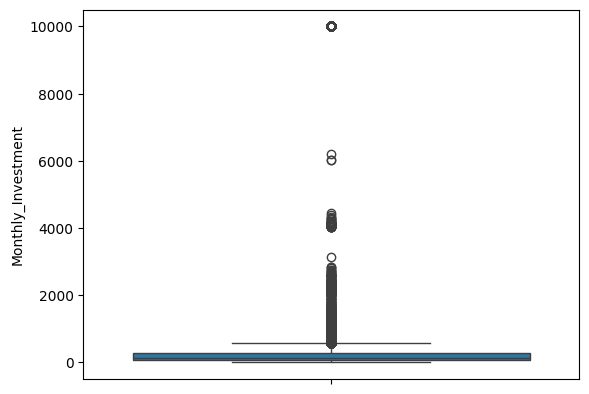

<Figure size 1000x1000 with 0 Axes>

In [168]:
sns.boxplot(train_df["Monthly_Investment"])
plt.figure(figsize=(10, 10))
plt.show()

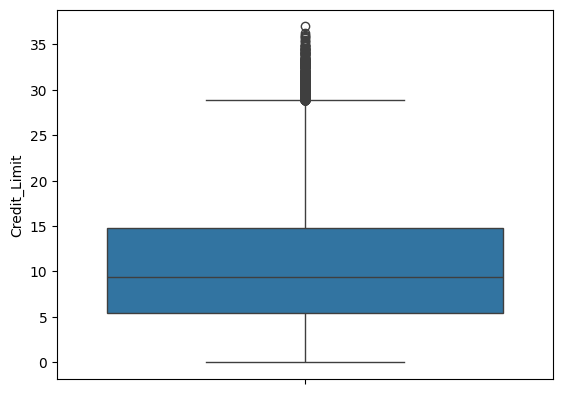

<Figure size 1000x1000 with 0 Axes>

In [169]:
sns.boxplot(train_df["Credit_Limit"])
plt.figure(figsize=(10, 10))
plt.show()

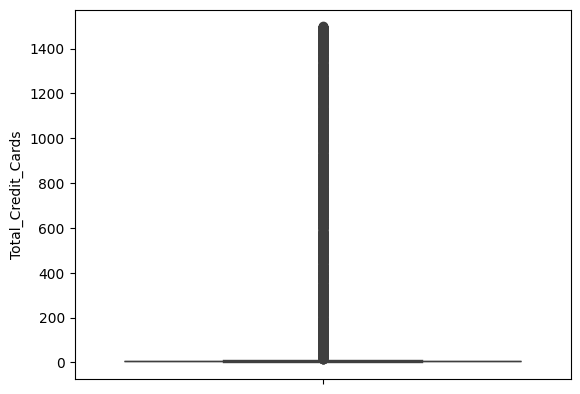

<Figure size 1000x1000 with 0 Axes>

In [170]:
sns.boxplot(train_df["Total_Credit_Cards"])
plt.figure(figsize=(10, 10))
plt.show()

In [171]:
class OutlierRemoval:
    def __init__(self, col):
        q1 = col.quantile(0.25)
        q3 = col.quantile(0.75)
        inter_quartile_range = q3 - q1
        self.upper_whisker = q3 + inter_quartile_range * 1.5
        self.lower_whisker = q1 - inter_quartile_range * 1.5

    def remove_outliers(self, df, column_name):
        # Remove rows where the column value is outside the whiskers
        return df[(df[column_name] >= self.lower_whisker) & (df[column_name] <= self.upper_whisker)]

    def fit_to_whisker(self, df, column_name):
        # Fit values greater than the upper whisker to the upper whisker
        # Fit values smaller than the lower whisker to the lower whisker
        df[column_name] = df[column_name].apply(
            lambda x: min(max(x, self.lower_whisker), self.upper_whisker)
        )
        return df

In [172]:
# outlier_columns=["Ratio_Credit_Utilization","Current_Debt_Outstanding","Credit_Limit","Delay_from_due_date","Base_Salary_PerMonth","Monthly_Investment"]
# # outlier_columns=["Ratio_Credit_Utilization","Current_Debt_Outstanding","Credit_Limit","Delay_from_due_date","Base_Salary_PerMonth"]
# for column in outlier_columns:
#     remover_column = OutlierRemoval(train_df[column])
#     train_df = remover_column.fit_to_whisker(train_df,column)

In [173]:
train_df

,ID,Month,Age,Profession,Income_Annual,Base_Salary_PerMonth,Total_Bank_Accounts,Total_Credit_Cards,Rate_Of_Interest,Total_Current_Loans,...,Credit_Score,Auto Loan,Credit-Builder Loan,Debt Consolidation Loan,Home Equity Loan,Mortgage Loan,Not Specified,Payday Loan,Personal Loan,Student Loan
0,0x522a,7,51.0,11.0,101583.480,8576.736000,5.0,7.0,10.0,4.0,...,1,0,0,1,0,0,0,1,0,1
1,0x6091,1,23.0,14.0,101926.950,8635.912500,4.0,4.0,9.0,1.0,...,1,0,0,0,0,1,0,0,0,0
2,0xcb5f,2,49.0,14.0,158871.120,13140.901333,0.0,4.0,8.0,1.0,...,1,0,0,0,1,0,0,0,0,0
3,0x17dbc,6,40.0,3.0,60379.280,4852.727333,5.0,6.0,18.0,3.0,...,1,0,1,0,0,1,0,0,1,0
4,0x225b3,5,17.0,0.0,50050.830,4085.902500,9.0,10.0,20.0,5.0,...,0,0,1,1,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,0x15619,1,55.0,3.0,114597.040,9465.233333,7.0,6.0,4.0,4.0,...,0,1,0,0,0,0,1,1,0,1
79996,0x3c48,4,28.0,5.0,8227.855,656.654583,6.0,8.0,31.0,100.0,...,0,1,1,0,0,0,1,0,1,0
79997,0x9589,1,46.0,14.0,35032.660,2853.388333,10.0,6.0,33.0,7.0,...,0,0,1,0,0,1,0,1,1,1
79998,0x74fe,7,42.0,9.0,129680.280,10643.690000,8.0,3.0,5.0,2.0,...,1,0,1,0,0,1,0,0,0,0


In [174]:
X = train_df.loc[:, 'Month':'Monthly_Balance']  # Features
y = train_df['Credit_Score']        # Target variable
X

,Month,Age,Profession,Income_Annual,Base_Salary_PerMonth,Total_Bank_Accounts,Total_Credit_Cards,Rate_Of_Interest,Total_Current_Loans,Delay_from_due_date,...,Total_Credit_Enquiries,Credit_Mix,Current_Debt_Outstanding,Ratio_Credit_Utilization,Credit_History_Age,Payment_of_Min_Amount,Per_Month_EMI,Monthly_Investment,Payment_Behaviour,Monthly_Balance
0,7,51.0,11.0,101583.480,8576.736000,5.0,7.0,10.0,4.0,8.0,...,5.0,2.0,50.93,34.462154,289.0,1.0,190.811017,630.015789,3.0,314.002193
1,1,23.0,14.0,101926.950,8635.912500,4.0,4.0,9.0,1.0,13.0,...,6.0,3.0,1058.00,39.693812,245.0,1.0,70.587681,662.803927,4.0,410.199642
2,2,49.0,14.0,158871.120,13140.901333,0.0,4.0,8.0,1.0,8.0,...,4.0,1.0,576.48,39.367225,228.0,1.0,86.905860,746.805985,4.0,742.514154
3,6,40.0,3.0,60379.280,4852.727333,5.0,6.0,18.0,3.0,15.0,...,1.0,2.0,725.39,29.061701,205.0,0.0,90.906385,166.418658,1.0,473.135623
4,5,17.0,0.0,50050.830,4085.902500,9.0,10.0,20.0,5.0,28.0,...,8.0,0.0,3419.10,30.386321,54.0,2.0,190.445060,56.789441,0.0,401.355749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,1,55.0,3.0,114597.040,9465.233333,7.0,6.0,4.0,4.0,32.0,...,2.0,1.0,926.18,26.436313,381.0,1.0,225.923762,327.619668,1.0,633.131903
79996,4,28.0,5.0,8227.855,656.654583,6.0,8.0,31.0,100.0,61.0,...,7.0,3.0,2695.38,24.127401,140.0,0.0,7352.000000,49.544158,4.0,268.108435
79997,1,46.0,14.0,35032.660,2853.388333,10.0,6.0,33.0,7.0,48.0,...,10.0,0.0,1789.00,25.086176,137.0,2.0,150.500097,106.735679,5.0,318.103057
79998,7,42.0,9.0,129680.280,10643.690000,8.0,3.0,5.0,2.0,27.0,...,6.0,3.0,240.27,33.944094,245.0,0.0,114.165609,567.179873,2.0,643.023518


In [175]:
skfold = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

In [176]:
# Define hyperparameter grid for Decision Tree
params = {
    "criterion":["entropy"], 
    "splitter":["best"], 
    "max_depth":[15], 
    "min_samples_split":[2], 
    "min_samples_leaf":[5], 
}
# Initialize and run GridSearchCV for Decision Tree

tree_clf = DecisionTreeClassifier(random_state=42)
tree_cv = GridSearchCV(tree_clf, params, scoring="accuracy", n_jobs=-1, verbose=1, cv=skfold)
tree_cv.fit(X, y)
best_params = tree_cv.best_params_
# Display best parameters and cross-validation accuracy
print(f"Best paramters: {best_params})")
print("Best Cross-Validation Accuracy:", tree_cv.best_score_)
# Get the best Decision Tree model
best_dtc = tree_cv.best_estimator_

Fitting 2 folds for each of 1 candidates, totalling 2 fits
Best paramters: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 5, 'min_samples_split': 2, 'splitter': 'best'})
Best Cross-Validation Accuracy: 0.6751125


In [177]:
# Define hyperparameter grid for Random Forest
n_estimators = [300]
max_features = ['sqrt']
max_depth = [None]
min_samples_split = [2]
min_samples_leaf = [3]
bootstrap = [True]
params_grid = {'n_estimators': n_estimators, 'max_features': max_features,
               'max_depth': max_depth, 'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf, 'bootstrap': bootstrap}

# Initialize and run GridSearchCV for Random Forest
rf_clf = RandomForestClassifier(random_state=42)
rf_cv = GridSearchCV(rf_clf, params_grid, scoring="accuracy", cv=skfold, verbose=2, n_jobs=-1)
rf_cv.fit(X, y)
best_params = rf_cv.best_params_
# Display best parameters and cross-validation accuracy
print(f"Best parameters: {best_params}")
print("Accuracy for Random Forest:", rf_cv.best_score_)
# Get the best Random Forest model
best_rf_model = rf_cv.best_estimator_

Fitting 2 folds for each of 1 candidates, totalling 2 fits
Best parameters: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 300}
Accuracy for Random Forest: 0.7548874999999999


In [188]:
#Define hyperparameter grid for XGBoost
xgb_param_grid = {
    'n_estimators': [200],
    'max_depth': [10],
    'learning_rate': [0.25],
    'gamma': [0.03]
}

# Initialize XGBoost Classifier
xgb_classifier = XGBClassifier(random_state=42)

# Initialize and run GridSearchCV for XGBoost
xgb_grid_search = GridSearchCV(estimator=xgb_classifier, param_grid=xgb_param_grid,
                               scoring='accuracy', cv=skfold, verbose=2, n_jobs=-1)
xgb_grid_search.fit(X, y)
# Display best parameters and cross-validation accuracy
print("Best parameters for XGBoost:", xgb_grid_search.best_params_)
print("Best Accuracy for XGBoost:", xgb_grid_search.best_score_)
# Get the best XGBoost model
best_xgb_model = xgb_grid_search.best_estimator_

Fitting 2 folds for each of 1 candidates, totalling 2 fits
Best parameters for XGBoost: {'gamma': 0.03, 'learning_rate': 0.25, 'max_depth': 10, 'n_estimators': 200}
Best Accuracy for XGBoost: 0.7618625


In [179]:
gaussian_classifier=GaussianNB()
gaussian_classifier.fit(X, y)
print("GaussianNB Model Accuracy:", gaussian_classifier.score(X, y))

GaussianNB Model Accuracy: 0.5281375


In [180]:
# Define hyperparameter grid for K-Nearest Neighbors
knn_param_grid = {
    'n_neighbors': [5],
    'weights': ['distance'],
    'metric': ['manhattan']
}

# Initialize and run GridSearchCV for KNN
knn_classifier = KNeighborsClassifier()
knn_grid_search = GridSearchCV(estimator=knn_classifier, param_grid=knn_param_grid,
                               scoring='accuracy', cv=skfold, verbose=2, n_jobs=-1)
knn_grid_search.fit(X, y)

# Display best parameters and cross-validation accuracy for KNN
print("Best parameters for KNN:", knn_grid_search.best_params_)
print("Best Accuracy for KNN:", knn_grid_search.best_score_)
# Get the best KNN model
best_knn_model = knn_grid_search.best_estimator_

Fitting 2 folds for each of 1 candidates, totalling 2 fits
Best parameters for KNN: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Best Accuracy for KNN: 0.69885


In [181]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
smote = SMOTE()
X_sm, y_sm = smote.fit_resample(X, y)

y_sm.value_counts()

Credit_Score
1    42539
0    42539
2    42539
Name: count, dtype: int64

In [182]:
# X_train_sm, X_test_sm, y_train_sm, y_test_sm = train_test_split(X_sm, y_sm, test_size=0.2, random_state=42, stratify=y_sm)

In [189]:
xgb_param_grid = {
    'n_estimators': [200],
    'max_depth': [15,10],
    'learning_rate': [0.5,0.25],
    'gamma': [0.03]
}

# Initialize XGBoost Classifier
xgb_classifier_2 = XGBClassifier(random_state=42)

# Initialize and run GridSearchCV for XGBoost
xgb_grid_search_2 = GridSearchCV(estimator=xgb_classifier, param_grid=xgb_param_grid,
                               scoring='accuracy', cv=3, verbose=2, n_jobs=-1)
xgb_grid_search_2.fit(X_sm, y_sm)
# Display best parameters and cross-validation accuracy
print("Best parameters for XGBoost:", xgb_grid_search_2.best_params_)
print("Best Accuracy for XGBoost:", xgb_grid_search_2.best_score_)
# Get the best XGBoost model
best_xgb_model_2 = xgb_grid_search_2.best_estimator_

# y_pred_xgb_2=best_xgb_model_2.predict(X_test_sm)
# accuracy_score(y_test_sm,y_pred_xgb_2)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best parameters for XGBoost: {'gamma': 0.03, 'learning_rate': 0.25, 'max_depth': 15, 'n_estimators': 200}
Best Accuracy for XGBoost: 0.7860708212855654


In [184]:
# Define hyperparameter grid for Random Forest
n_estimators = [200]
max_features = ['sqrt']
max_depth = [None]
min_samples_split = [2]
min_samples_leaf = [4]
bootstrap = [True]
params_grid = {'n_estimators': n_estimators, 'max_features': max_features,
               'max_depth': max_depth, 'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf, 'bootstrap': bootstrap}

# Initialize and run GridSearchCV for Random Forest
rf_clf_2 = RandomForestClassifier(random_state=42)
rf_cv_2 = GridSearchCV(rf_clf_2, params_grid, scoring="accuracy", cv=3, verbose=2, n_jobs=-1)
rf_cv_2.fit(X_sm, y_sm)
best_params = rf_cv_2.best_params_
# Display best parameters and cross-validation accuracy
print(f"Best parameters: {best_params}")
print("Accuracy for Random Forest:", rf_cv_2.best_score_)
# Get the best Random Forest model
best_rf_model_2 = rf_cv_2.best_estimator_
# y_pred_rf=best_rf_model_2.predict(X_test_sm)
# accuracy_score(y_test_sm,y_pred_rf)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best parameters: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy for Random Forest: 0.7806013305437364


In [190]:
# Predict using XGBoost model on test dataset
X_test_df=test_df.loc[:, 'Month':'Monthly_Balance']
predictions = best_xgb_model_2.predict(X_test_df)
mapped_predictions = np.select(
    [predictions == 0, predictions == 1, predictions == 2],
    ['Poor', 'Standard', 'Good']
)
mapped_predictions

output_df = pd.DataFrame({
    'ID': test_df['ID'],  # Use 'PassengerId' from the test dataset
    'Credit_Score': mapped_predictions                    # Use the predicted 'Survived' values
})

# Save the predictions to a CSV file
output_df.to_csv('xgb.csv', index=False)